# Context Quality Evaluation Analysis

This notebook analyzes the results of evaluating definition and guideline quality across GAIC datasets.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load results
with open('context_quality_eval_vertex-ai_anthropic_claude-opus-4-6_20260313_162402.json', 'r') as f:
    results = json.load(f)

print(f"Model: {results['model']}")
print(f"Sample size per dataset: {results['sample_size']}")
print(f"Datasets: {list(results['task_a'].keys())}")

Model: @vertex-ai/anthropic.claude-opus-4-6
Sample size per dataset: 10
Datasets: ['ABSTRCT', 'ACQUA', 'AEC', 'AFS', 'ARGUMINSCI', 'FINARG', 'IAM', 'PE', 'SCIARK', 'USELEC']


## Task A: Definition Quality (Label Explainability)

Evaluates how well each dataset's definition explains the assigned labels.

In [2]:
# Extract Task A data
task_a_rows = []
for dataset, data in results['task_a'].items():
    for sample in data['samples']:
        task_a_rows.append({
            'dataset': dataset,
            'id': sample['id'],
            'label': sample['label'],
            'score': sample['evaluation']['score'],
            'label_derivable': sample['evaluation']['label_derivable'],
            'reasoning': sample['evaluation']['reasoning']
        })

df_task_a = pd.DataFrame(task_a_rows)
print(f"Total samples evaluated: {len(df_task_a)}")
df_task_a.head()

Total samples evaluated: 100


,dataset,id,label,score,label_derivable,reasoning
0,ABSTRCT,ABSTRCT-dev-1,Argument,3,False,This sentence expresses a general statement ab...
1,ABSTRCT,ABSTRCT-dev-2,Argument,5,True,This sentence is a concluding statement made b...
2,ABSTRCT,ABSTRCT-dev-3,Argument,4,True,This sentence functions as a claim — it is a c...
3,ABSTRCT,ABSTRCT-dev-4,Argument,2,False,This sentence is a background/context statemen...
4,ABSTRCT,ABSTRCT-dev-5,Argument,5,True,This sentence is a concluding statement made b...


In [3]:
# Aggregate Task A metrics per dataset
task_a_summary = df_task_a.groupby('dataset').agg({
    'score': ['mean', 'std', 'median'],
    'label_derivable': 'mean'  # Proportion of samples where label is derivable
}).round(2)

task_a_summary.columns = ['Mean Score', 'Std', 'Median Score', 'Derivability Rate']
task_a_summary = task_a_summary.sort_values('Mean Score', ascending=False)
task_a_summary

,Mean Score,Std,Median Score,Derivability Rate
dataset,,,,
ACQUA,4.0,1.05,4.0,0.7
IAM,4.0,1.05,4.0,0.7
SCIARK,3.9,1.20,4.0,0.7
AFS,3.8,0.92,4.0,0.7
FINARG,3.8,0.92,4.0,0.7
ARGUMINSCI,3.6,0.52,4.0,0.7
PE,3.6,1.17,3.5,0.6
AEC,3.5,0.85,3.0,0.4
ABSTRCT,3.4,1.17,3.5,0.5


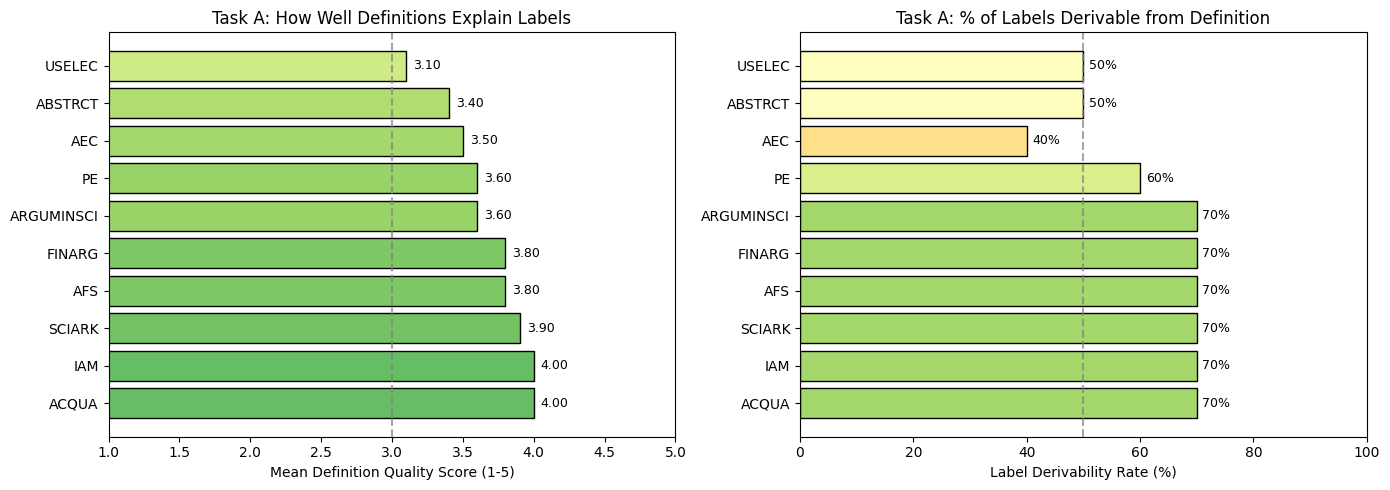

In [4]:
# Visualize Task A: Mean scores per dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean Score per dataset
ax1 = axes[0]
datasets_sorted = task_a_summary.index.tolist()
colors = plt.cm.RdYlGn(task_a_summary['Mean Score'] / 5)

bars = ax1.barh(datasets_sorted, task_a_summary['Mean Score'], color=colors, edgecolor='black')
ax1.set_xlabel('Mean Definition Quality Score (1-5)')
ax1.set_title('Task A: How Well Definitions Explain Labels')
ax1.axvline(x=3, color='gray', linestyle='--', alpha=0.7, label='Neutral (3)')
ax1.set_xlim(1, 5)

# Add value labels
for bar, score in zip(bars, task_a_summary['Mean Score']):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
             f'{score:.2f}', va='center', fontsize=9)

# Plot 2: Derivability rate
ax2 = axes[1]
colors2 = plt.cm.RdYlGn(task_a_summary['Derivability Rate'])
bars2 = ax2.barh(datasets_sorted, task_a_summary['Derivability Rate'] * 100, color=colors2, edgecolor='black')
ax2.set_xlabel('Label Derivability Rate (%)')
ax2.set_title('Task A: % of Labels Derivable from Definition')
ax2.axvline(x=50, color='gray', linestyle='--', alpha=0.7)
ax2.set_xlim(0, 100)

for bar, rate in zip(bars2, task_a_summary['Derivability Rate']):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{rate*100:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('task_a_definition_quality.png', dpi=150, bbox_inches='tight')
plt.show()

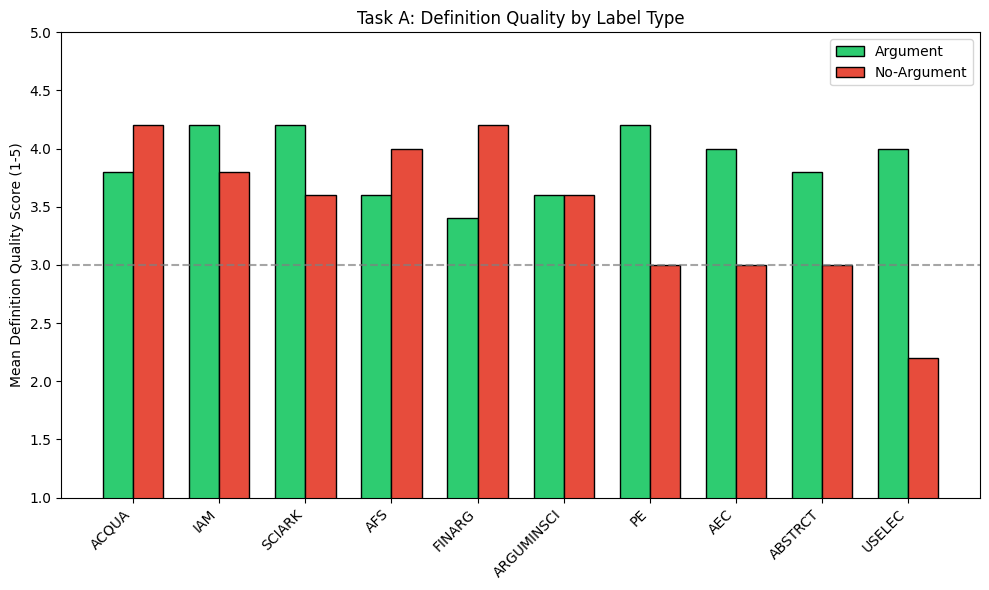

In [5]:
# Score distribution by label type (Argument vs No-Argument)
fig, ax = plt.subplots(figsize=(10, 6))

# Create grouped bar chart
task_a_by_label = df_task_a.groupby(['dataset', 'label'])['score'].mean().unstack()
task_a_by_label = task_a_by_label.reindex(datasets_sorted)

x = np.arange(len(datasets_sorted))
width = 0.35

bars1 = ax.bar(x - width/2, task_a_by_label['Argument'], width, label='Argument', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, task_a_by_label['No-Argument'], width, label='No-Argument', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Mean Definition Quality Score (1-5)')
ax.set_title('Task A: Definition Quality by Label Type')
ax.set_xticks(x)
ax.set_xticklabels(datasets_sorted, rotation=45, ha='right')
ax.legend()
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.7)
ax.set_ylim(1, 5)

plt.tight_layout()
plt.savefig('task_a_by_label.png', dpi=150, bbox_inches='tight')
plt.show()

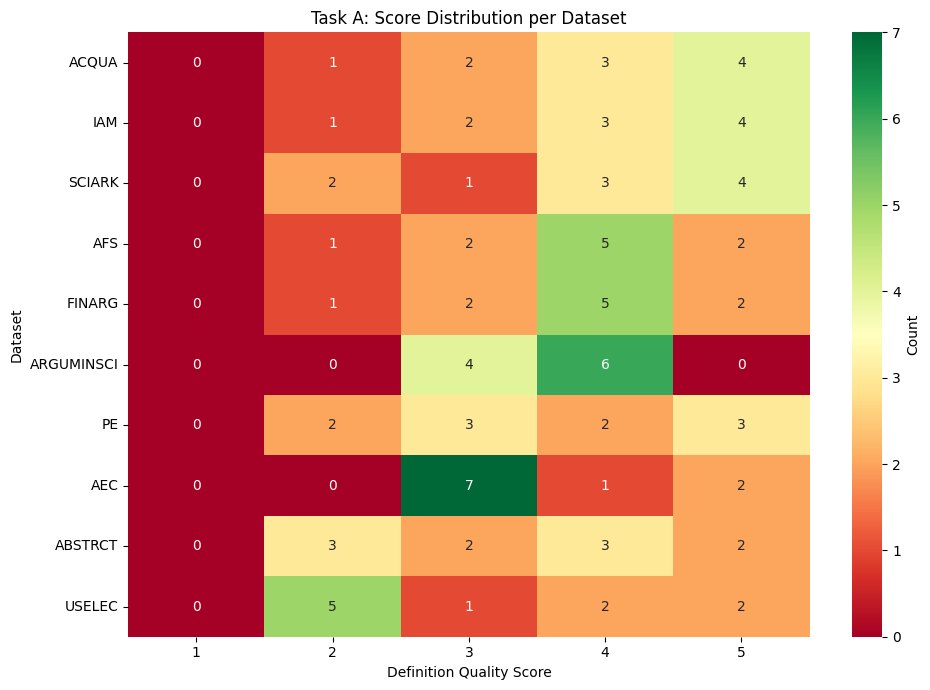

In [6]:
# Heatmap of score distribution
fig, ax = plt.subplots(figsize=(10, 7))

score_dist = df_task_a.groupby(['dataset', 'score']).size().unstack(fill_value=0)
score_dist = score_dist.reindex(datasets_sorted)

# Ensure all score columns exist
for s in range(1, 6):
    if s not in score_dist.columns:
        score_dist[s] = 0
score_dist = score_dist[[1, 2, 3, 4, 5]]

sns.heatmap(score_dist, annot=True, fmt='d', cmap='RdYlGn', 
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Definition Quality Score')
ax.set_ylabel('Dataset')
ax.set_title('Task A: Score Distribution per Dataset')

plt.tight_layout()
plt.savefig('task_a_score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Task B: Definition-Guideline Alignment

Evaluates consistency between the argument definition and annotation guidelines for each dataset.

In [7]:
# Extract Task B data
task_b_rows = []
for dataset, data in results['task_b'].items():
    task_b_rows.append({
        'dataset': dataset,
        'score': data['score'],
        'reasoning': data['reasoning'],
        'gaps_in_definition': data['gaps_in_definition'],
        'gaps_in_guidelines': data['gaps_in_guidelines']
    })

df_task_b = pd.DataFrame(task_b_rows)
df_task_b = df_task_b.set_index('dataset').reindex(datasets_sorted).reset_index()
df_task_b

,dataset,score,reasoning,gaps_in_definition,gaps_in_guidelines
0,ACQUA,NaN,NaN,NaN,NaN
1,IAM,NaN,NaN,NaN,NaN
2,SCIARK,NaN,NaN,NaN,NaN
3,AFS,NaN,NaN,NaN,NaN
4,FINARG,NaN,NaN,NaN,NaN
5,ARGUMINSCI,4.0,The definition and guidelines are mostly align...,The definition lacks explicit criteria for dis...,The guidelines do not explicitly mention that ...
6,PE,4.0,The definition and guidelines are mostly align...,Practical annotation decisions missing from th...,The guidelines do not explicitly mention 'majo...
7,AEC,NaN,NaN,NaN,NaN
8,ABSTRCT,2.0,The definition identifies two types of argumen...,The definition does not address the guideline'...,The guideline does not account for the definit...
9,USELEC,4.0,The definition and guidelines are mostly align...,"No mention of: clause-level segmentation, prac...",none


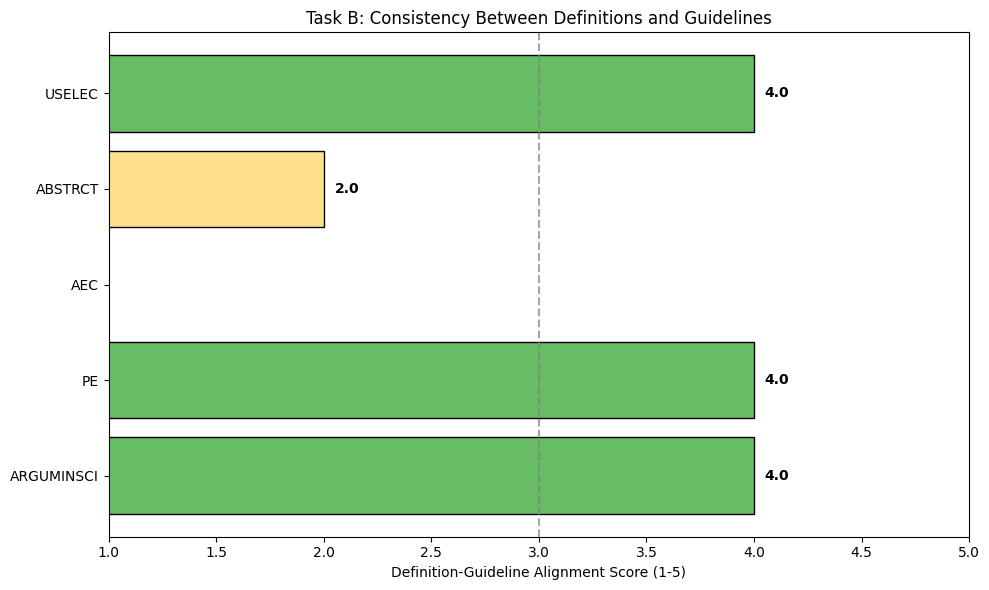

In [8]:
# Visualize Task B
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn(df_task_b['score'] / 5)
bars = ax.barh(df_task_b['dataset'], df_task_b['score'], color=colors, edgecolor='black')

ax.set_xlabel('Definition-Guideline Alignment Score (1-5)')
ax.set_title('Task B: Consistency Between Definitions and Guidelines')
ax.axvline(x=3, color='gray', linestyle='--', alpha=0.7, label='Partial alignment (3)')
ax.set_xlim(1, 5)

for bar, score in zip(bars, df_task_b['score']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
             f'{score}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('task_b_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

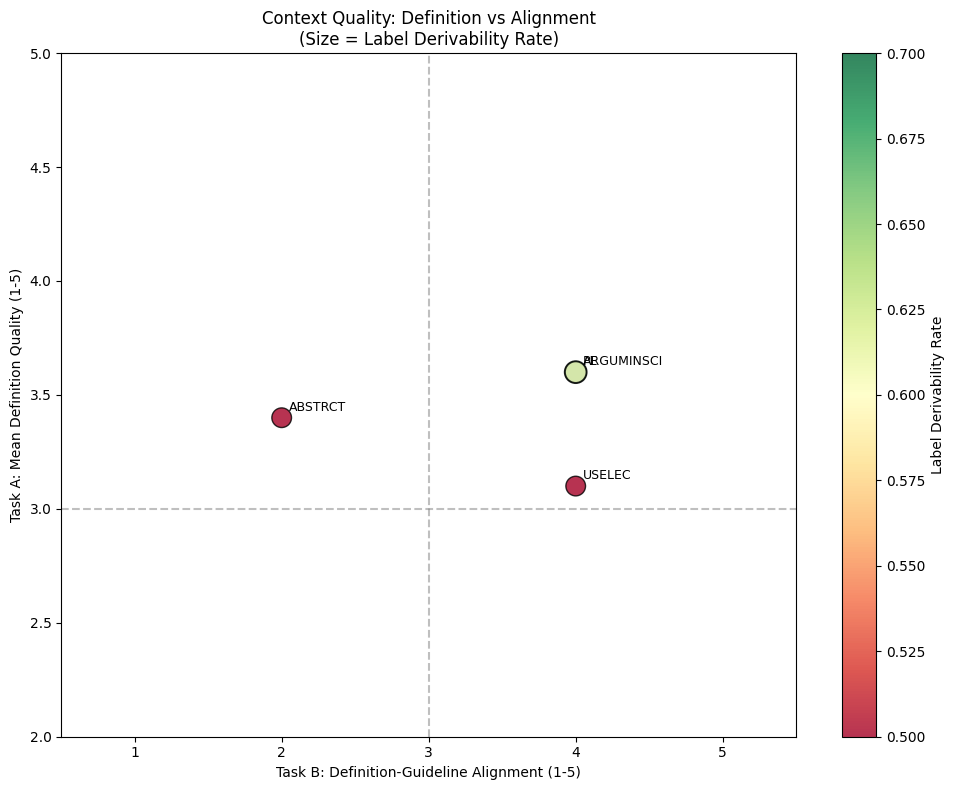

In [9]:
# Combined view: Task A mean score vs Task B alignment
fig, ax = plt.subplots(figsize=(10, 8))

# Merge task A summary with task B
combined = task_a_summary.reset_index().merge(
    df_task_b[['dataset', 'score']], 
    on='dataset'
)
combined = combined.rename(columns={'score': 'Alignment Score'})

# Scatter plot
scatter = ax.scatter(
    combined['Alignment Score'], 
    combined['Mean Score'],
    s=combined['Derivability Rate'] * 300 + 50,  # Size by derivability
    c=combined['Derivability Rate'],
    cmap='RdYlGn',
    edgecolors='black',
    alpha=0.8
)

# Add labels
for _, row in combined.iterrows():
    ax.annotate(row['dataset'], 
                (row['Alignment Score'], row['Mean Score']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('Task B: Definition-Guideline Alignment (1-5)')
ax.set_ylabel('Task A: Mean Definition Quality (1-5)')
ax.set_title('Context Quality: Definition vs Alignment\n(Size = Label Derivability Rate)')
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=3, color='gray', linestyle='--', alpha=0.5)
ax.set_xlim(0.5, 5.5)
ax.set_ylim(2, 5)

# Colorbar for derivability
cbar = plt.colorbar(scatter)
cbar.set_label('Label Derivability Rate')

plt.tight_layout()
plt.savefig('context_quality_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics

In [10]:
# Overall summary
print("=" * 60)
print("OVERALL SUMMARY")
print("=" * 60)
print(f"\nTask A - Definition Quality:")
print(f"  Mean score across all samples: {df_task_a['score'].mean():.2f}")
print(f"  Overall derivability rate: {df_task_a['label_derivable'].mean()*100:.1f}%")
print(f"  Best dataset: {task_a_summary['Mean Score'].idxmax()} ({task_a_summary['Mean Score'].max():.2f})")
print(f"  Worst dataset: {task_a_summary['Mean Score'].idxmin()} ({task_a_summary['Mean Score'].min():.2f})")

print(f"\nTask B - Definition-Guideline Alignment:")
print(f"  Mean alignment score: {df_task_b['score'].mean():.2f}")
print(f"  Best aligned: {df_task_b.loc[df_task_b['score'].idxmax(), 'dataset']} ({df_task_b['score'].max()})")
print(f"  Worst aligned: {df_task_b.loc[df_task_b['score'].idxmin(), 'dataset']} ({df_task_b['score'].min()})")

OVERALL SUMMARY

Task A - Definition Quality:
  Mean score across all samples: 3.67
  Overall derivability rate: 62.0%
  Best dataset: ACQUA (4.00)
  Worst dataset: USELEC (3.10)

Task B - Definition-Guideline Alignment:
  Mean alignment score: 3.50
  Best aligned: ARGUMINSCI (4.0)
  Worst aligned: ABSTRCT (2.0)


In [11]:
# Detailed gaps analysis from Task B
print("\n" + "=" * 60)
print("DEFINITION-GUIDELINE GAPS ANALYSIS")
print("=" * 60)

for _, row in df_task_b.iterrows():
    print(f"\n{row['dataset']} (Score: {row['score']})")
    print("-" * 40)
    print(f"Gaps in Definition: {row['gaps_in_definition'][:200]}..." if len(str(row['gaps_in_definition'])) > 200 else f"Gaps in Definition: {row['gaps_in_definition']}")
    print(f"Gaps in Guidelines: {row['gaps_in_guidelines'][:200]}..." if len(str(row['gaps_in_guidelines'])) > 200 else f"Gaps in Guidelines: {row['gaps_in_guidelines']}")


DEFINITION-GUIDELINE GAPS ANALYSIS

ACQUA (Score: nan)
----------------------------------------
Gaps in Definition: nan
Gaps in Guidelines: nan

IAM (Score: nan)
----------------------------------------
Gaps in Definition: nan
Gaps in Guidelines: nan

SCIARK (Score: nan)
----------------------------------------
Gaps in Definition: nan
Gaps in Guidelines: nan

AFS (Score: nan)
----------------------------------------
Gaps in Definition: nan
Gaps in Guidelines: nan

FINARG (Score: nan)
----------------------------------------
Gaps in Definition: nan
Gaps in Guidelines: nan

ARGUMINSCI (Score: 4.0)
----------------------------------------
Gaps in Definition: The definition lacks explicit criteria for distinguishing non-argumentative text (e.g., purely descriptive, definitional, procedural, mathematical content; proposals/announcements without asserted pro...
Gaps in Guidelines: The guidelines do not explicitly mention that argumentative component spans can range from a single token to mu

In [12]:
# Samples with lowest scores (problematic definitions)
print("\n" + "=" * 60)
print("SAMPLES WITH LOWEST DEFINITION QUALITY (Score <= 2)")
print("=" * 60)

low_quality = df_task_a[df_task_a['score'] <= 2].sort_values('score')
print(f"\nTotal problematic samples: {len(low_quality)} / {len(df_task_a)} ({len(low_quality)/len(df_task_a)*100:.1f}%)")

for _, row in low_quality.head(10).iterrows():
    print(f"\n[{row['dataset']}] {row['id']} - Score: {row['score']}")
    print(f"Label: {row['label']}")
    print(f"Reasoning: {row['reasoning'][:300]}..." if len(row['reasoning']) > 300 else f"Reasoning: {row['reasoning']}")


SAMPLES WITH LOWEST DEFINITION QUALITY (Score <= 2)

Total problematic samples: 16 / 100 (16.0%)

[ABSTRCT] ABSTRCT-dev-4 - Score: 2
Label: Argument
Reasoning: This sentence is a background/context statement about the state of ovarian cancer treatment, not a concluding claim about the outcome of the study, nor an observation or measurement from the study. It does not describe a relationship between an intervention and control, nor does it report any eviden...

[ABSTRCT] ABSTRCT-dev-172 - Score: 2
Label: No-Argument
Reasoning: This sentence presents specific measurements and observations from the study (IOP targets achieved, percentages, P-value), which closely matches the definition of 'Evidence' — 'an observation or measurement in the study, such as outcomes or side effects.' The sentence reports concrete numerical outc...

[ABSTRCT] ABSTRCT-dev-173 - Score: 2
Label: No-Argument
Reasoning: This sentence reports a specific observation/measurement from the study (Grade 3/4 neutropenia 